In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from SVM.final_project.wine_fraud import param_grid
from xgboost.dask import predict

In [2]:
df = pd.read_csv("mushrooms.csv")

In [3]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
X = df.drop('class', axis=1)

In [5]:
X = pd.get_dummies(X, drop_first=True)

In [6]:
y = df['class']

In [7]:
X.head()

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [8]:
y.head()

0    p
1    e
2    e
3    p
4    e
Name: class, dtype: str

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=101)

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

In [13]:
help(GradientBoostingClassifier)

Help on class GradientBoostingClassifier in module sklearn.ensemble._gb:

class GradientBoostingClassifier(sklearn.base.ClassifierMixin, BaseGradientBoosting)
 |  GradientBoostingClassifier(*, loss='log_loss', learning_rate=0.1, n_estimators=100, subsample=1.0, criterion='deprecated', min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_depth=3, min_impurity_decrease=0.0, init=None, random_state=None, max_features=None, verbose=0, max_leaf_nodes=None, warm_start=False, validation_fraction=0.1, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)
 |  
 |  Gradient Boosting for classification.
 |  
 |  This algorithm builds an additive model in a forward stage-wise fashion; it
 |  allows for the optimization of arbitrary differentiable loss functions. In
 |  each stage ``n_classes_`` regression trees are fit on the negative gradient
 |  of the loss function, e.g. binary or multiclass log loss. Binary
 |  classification is a special case where only a single regression t

In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
param_grid = {
    "n_estimators": [1,5,20,40,100],
    "max_depth": [3,4,5,6],
}

In [16]:
gb_model = GradientBoostingClassifier()

In [17]:
grid = GridSearchCV(gb_model, param_grid)

In [18]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'n_estimators': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information pr

In [19]:
grid.best_params_

{'max_depth': 3, 'n_estimators': 100}

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [21]:
predictions = grid.predict(X_test)

In [22]:
predictions

array(['p', 'e', 'p', ..., 'p', 'p', 'e'], shape=(1219,), dtype=object)

In [24]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       655
           p       1.00      1.00      1.00       564

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



In [27]:
grid.best_estimator_.feature_importances_

array([2.91150176e-04, 4.30919234e-17, 0.00000000e+00, 0.00000000e+00,
       2.60154066e-17, 1.04524302e-03, 5.61629257e-18, 5.06011038e-06,
       0.00000000e+00, 0.00000000e+00, 3.32375935e-17, 6.40606225e-18,
       1.48085008e-16, 5.54880262e-18, 1.59436391e-17, 2.15478205e-06,
       2.31053911e-03, 5.17802023e-02, 1.84253604e-04, 1.72402480e-02,
       1.82499853e-02, 9.44107255e-05, 6.14744469e-01, 8.63939501e-03,
       0.00000000e+00, 0.00000000e+00, 1.37748041e-18, 1.25092906e-02,
       1.11958495e-02, 0.00000000e+00, 1.98615541e-16, 0.00000000e+00,
       4.22818328e-17, 5.48918983e-18, 0.00000000e+00, 0.00000000e+00,
       7.17987453e-17, 0.00000000e+00, 1.11008688e-16, 0.00000000e+00,
       6.43330480e-04, 2.92091629e-04, 1.35978918e-01, 0.00000000e+00,
       3.23882633e-02, 2.52880997e-03, 8.16239925e-04, 6.53890008e-05,
       1.76797782e-05, 7.74443653e-05, 3.37081895e-02, 1.75969359e-04,
       0.00000000e+00, 0.00000000e+00, 1.22682934e-03, 0.00000000e+00,
      

In [28]:
feat_import = grid.best_estimator_.feature_importances_

In [29]:
imp_feats = pd.DataFrame(index = X.columns, data = feat_import, columns=['importance'] )

In [30]:
imp_feats

,importance
cap-shape_c,2.911502e-04
cap-shape_f,4.309192e-17
cap-shape_k,0.000000e+00
cap-shape_s,0.000000e+00
cap-shape_x,2.601541e-17
...,...
habitat_l,0.000000e+00
habitat_m,7.208898e-18
habitat_p,0.000000e+00
habitat_u,1.004851e-05


In [32]:
imp_feats.sort_values("importance", ascending=False)

,importance
odor_n,0.614744
stalk-root_c,0.135979
bruises_t,0.051780
stalk-surface-below-ring_y,0.033708
stalk-root_r,0.032388
...,...
spore-print-color_y,0.000000
population_n,0.000000
habitat_l,0.000000
habitat_p,0.000000


In [33]:
imp_feats.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
importance,95.0,0.010526,0.064639,0.0,0.0,1.480850e-16,0.000468,0.614744


In [36]:
imp_feats = imp_feats[imp_feats["importance"] > 0.000527]

In [38]:
imp_feats.sort_values("importance", ascending=False)

,importance
odor_n,0.614744
stalk-root_c,0.135979
bruises_t,0.051780
stalk-surface-below-ring_y,0.033708
stalk-root_r,0.032388
spore-print-color_r,0.030495
odor_l,0.018250
odor_f,0.017240
gill-spacing_w,0.012509
gill-size_n,0.011196


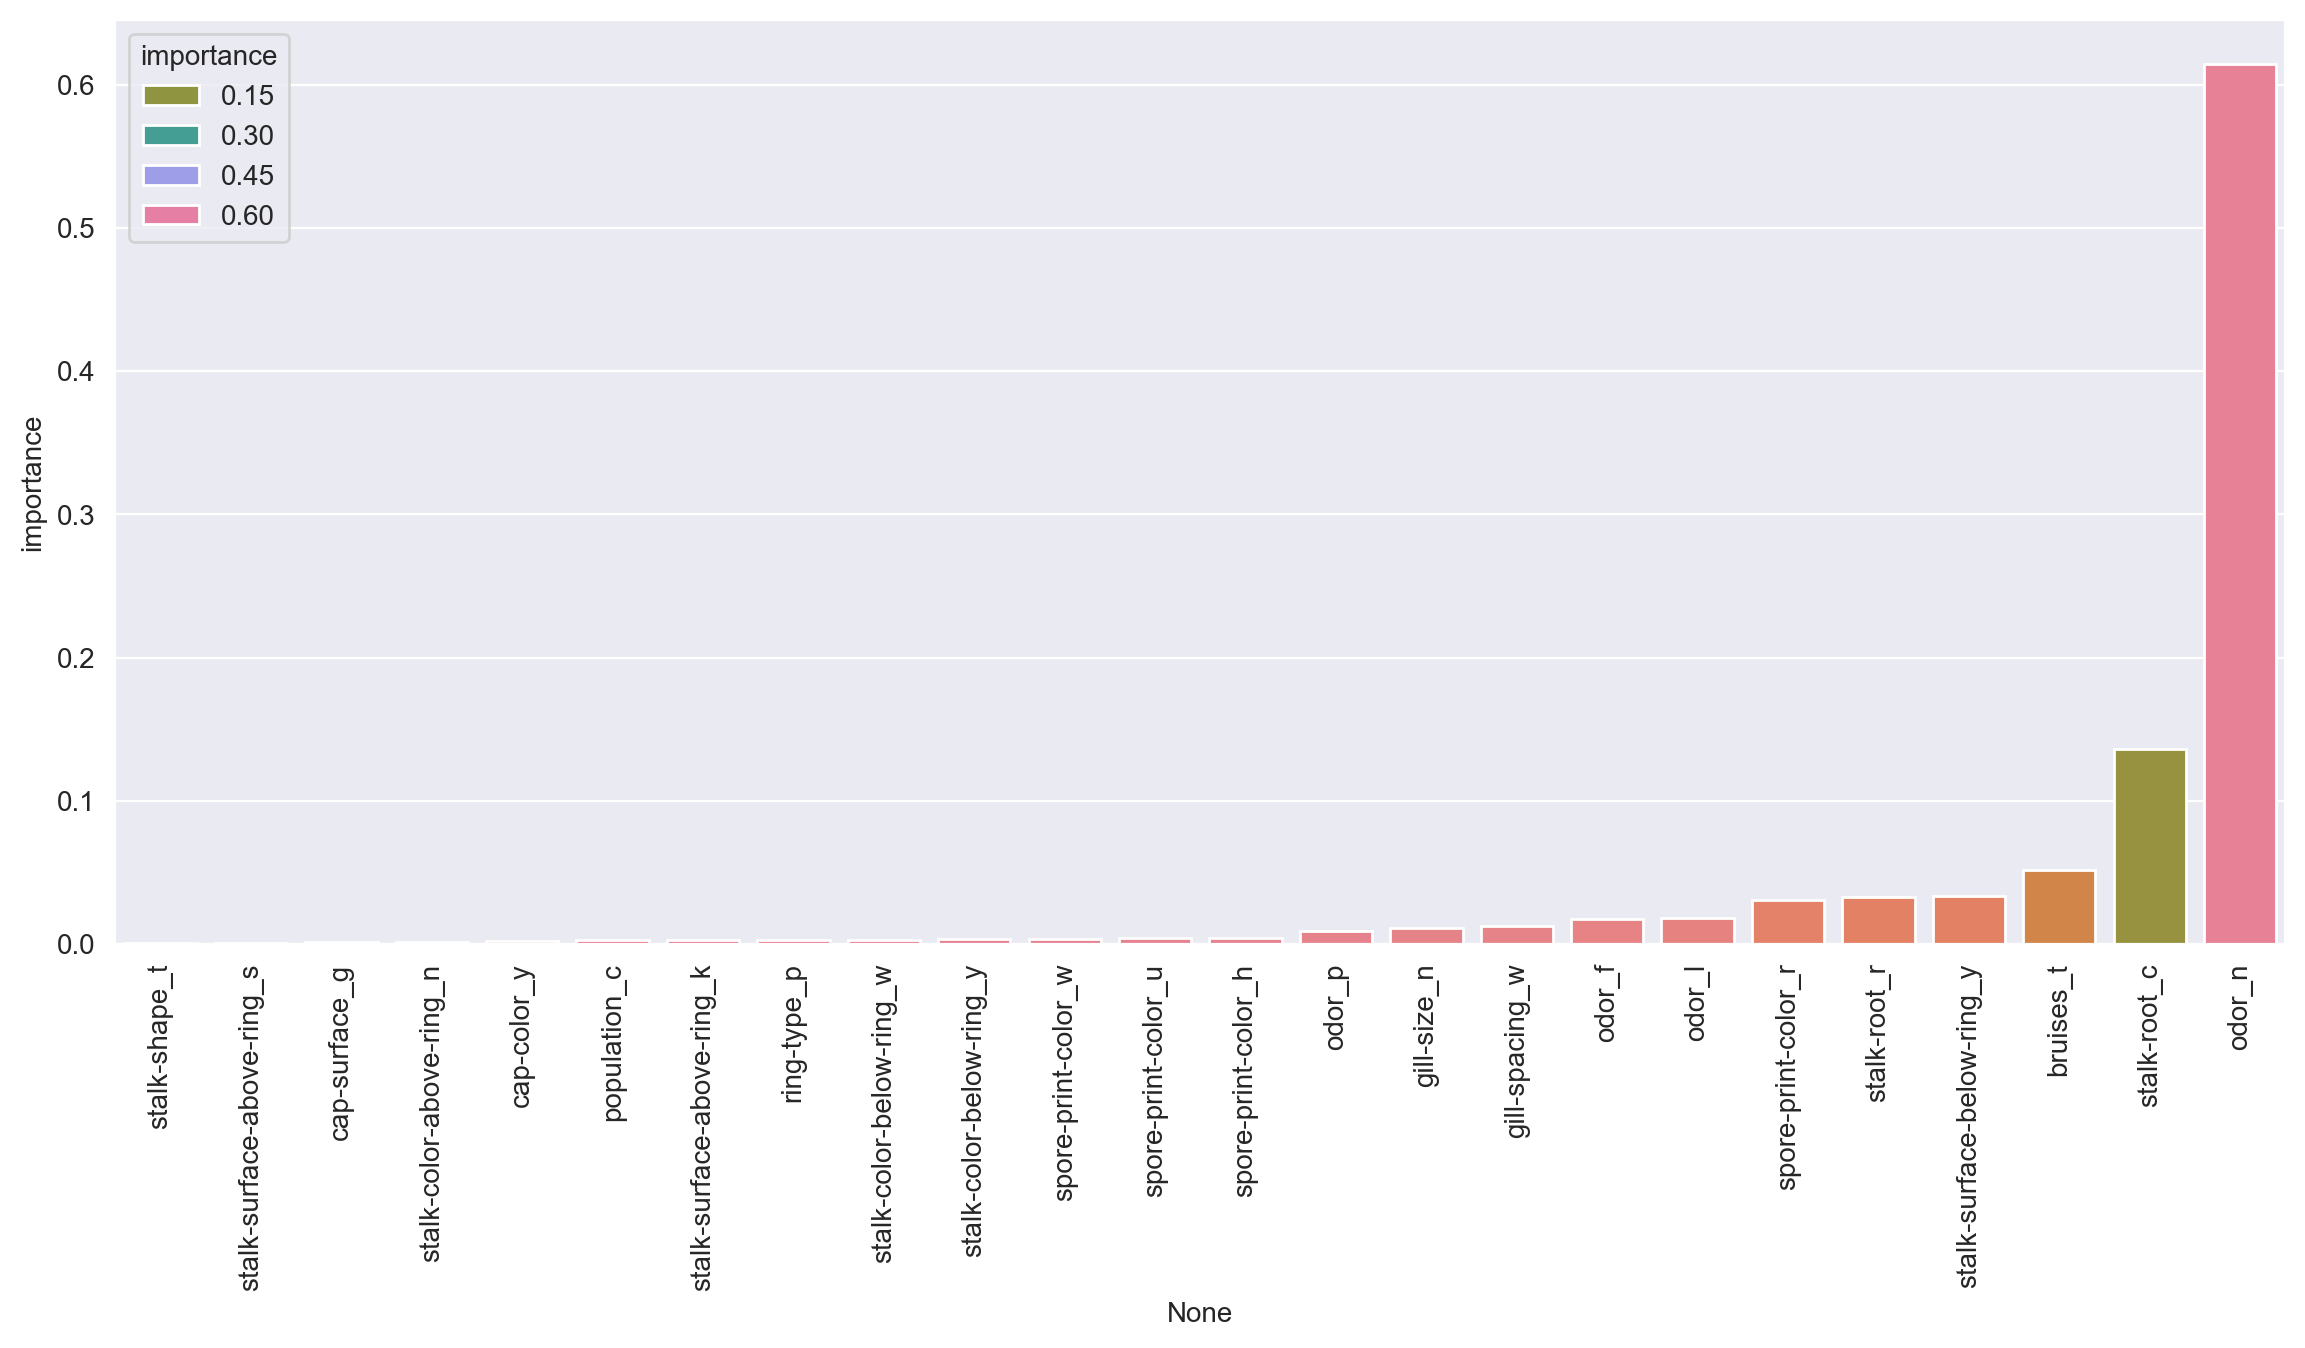

In [47]:
plt.figure(figsize=(14, 6), dpi=200)

sns.barplot(
    data=imp_feats.sort_values("importance"),
    x=imp_feats.sort_values("importance").index,
    y="importance",
    palette="husl",
    hue="importance"
)

plt.xticks(rotation=90)
plt.show()